# Investigation 02 - 4D Metric Correlation Bubble Plot


In [49]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [50]:
# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Colon"   # "Colon", "Duodenum", or None
ORGAN_COLUMN = "Organ"
NO_SELF = True
SUBSET_RULE_ITEMS_MAX = 3
SUBSET_MIN_SUPPORT = 0.015
STAGE_COLUMN = "Pathological score"
FDR_COLUMN = "FDR"
FDR_MAX = 0.05

STAGE = "Mild"  # e.g., "Control", "Mild", "Severe", or 0, 1, 2
# ---------- Bubble thresholds ----------
POS_LEVERAGE_MIN = 0.05
POS_LIFT_MIN = 1.3
NEG_LEVERAGE_MAX = -0.05
NEG_LIFT_MAX = 0.6

# ---------- Bubble display ----------
MIN_SUPPORT_FOR_BUBBLE = 0.0
BUBBLE_SIZE_SCALE = 2000
NOISE_LEVERAGE_ABS = 0.01
NOISE_LIFT_RANGE = (0.8, 1.2)

# ---------- Data path ----------
ALGO = "fpgrowth"  # e.g., "fpgrowth", "weighted_fpgrowth"
DATA_ROOT = fr"results\full_run\{ALGO}\data"
RAW_RESULTS_FILE = os.path.join("..", "..", DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_MAX:", SUBSET_RULE_ITEMS_MAX)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("FDR_MAX:", FDR_MAX)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)

# ---------- Highlight specific rules ----------
HIGHLIGHT_RULES = [
    r"Paneth.*->.*Epithelial.*",
    r"Macrophage.*->.*Epithelial.*",
    r"Plasma.*->.*Epithelial.*",
    r"CD8T.*->.*Epithelial.*",
    r"Neutrophil.*->.*Epithelial.*",
    r"Macrophage.*-> CD8T.*",
    r"Endocrine.*->.*Muscle.*",
    r"Fibroblast.*->.*Epithelial.*"
]


METHOD: CN
ORGAN: Colon
NO_SELF: True
SUBSET_RULE_ITEMS_MAX: 3
SUBSET_MIN_SUPPORT: 0.015
FDR_MAX: 0.05
RAW_RESULTS_FILE: ..\..\results\full_run\fpgrowth\data\results_CN.csv


In [51]:
def _plot_metric_bubble(metric_df, leverage_source):
    if metric_df.empty:
        print("No rows after filtering. Adjust filters or thresholds.")
        return None

    fig, ax = plt.subplots(figsize=(14, 10))

    scatter = ax.scatter(
        metric_df["Leverage"],
        metric_df["Log2_Lift"],
        s=metric_df["Bubble_Size"],
        c=metric_df["Confidence"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3,
    )

    ax.axvline(0, color="gray", linewidth=1.0)
    ax.axhline(0, color="gray", linewidth=1.0)
    ax.axvline(POS_LEVERAGE_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
    ax.axvline(NEG_LEVERAGE_MAX, color="royalblue", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)

    x_min, x_max = metric_df["Leverage"].min(), metric_df["Leverage"].max()
    y_min, y_max = metric_df["Log2_Lift"].min(), metric_df["Log2_Lift"].max()

    if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
        pos_rect = Rectangle(
            (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
            x_max - POS_LEVERAGE_MIN,
            y_max - np.log2(POS_LIFT_MIN),
            fill=False,
            edgecolor="tomato",
            linewidth=1.2,
        )
        ax.add_patch(pos_rect)

    if x_min < NEG_LEVERAGE_MAX and y_min < np.log2(NEG_LIFT_MAX):
        neg_rect = Rectangle(
            (x_min, y_min),
            NEG_LEVERAGE_MAX - x_min,
            np.log2(NEG_LIFT_MAX) - y_min,
            fill=False,
            edgecolor="royalblue",
            linewidth=1.2,
        )
        ax.add_patch(neg_rect)

    colorbar = plt.colorbar(scatter, ax=ax)
    colorbar.set_label("Confidence")

    # --- Highlight specific rules ---
    if "HIGHLIGHT_RULES" in globals() and HIGHLIGHT_RULES:
        import re
        pattern = "|".join(HIGHLIGHT_RULES)
        mask = metric_df["Rule"].str.contains(pattern, regex=True, na=False)
        hl_df = metric_df[mask]
        if not hl_df.empty:
            ax.scatter(
                hl_df["Leverage"],
                hl_df["Log2_Lift"],
                s=hl_df["Bubble_Size"],
                facecolors="none",
                edgecolors="red",
                linewidths=2.5,
                zorder=5,
            )
            from adjustText import adjust_text
            texts = []
            for _, row in hl_df.iterrows():
                texts.append(ax.text(
                    row["Leverage"],
                    row["Log2_Lift"],
                    row["Rule"],
                    color="red",
                    fontsize=9,
                    zorder=6,
                ))
            adjust_text(texts, arrowprops=dict(arrowstyle="-", color='red', lw=0.5))

    supports = metric_df["Support"].quantile([0.1, 0.5, 0.75, 0.9]).values
    handles = [
        ax.scatter([], [], s=max(s * BUBBLE_SIZE_SCALE, 10), color="gray", alpha=0.35, edgecolors="none")
        for s in supports
    ]
    labels = [f"Support {s:.3f}" for s in supports]
    ax.legend(handles, labels, title="Bubble size", loc="upper left")

    positive_count = int(((metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))).sum())
    negative_count = int(((metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))).sum())
    dot_count = int(metric_df.shape[0])

    organ_text = ORGAN if ORGAN is not None else "All"
    stage_text = STAGE if STAGE is not None else "All"
    
    title_lines = [
        f"4D Metric Correlation Bubble Plot ({METHOD} | {ALGO})",
        f"Organ: {organ_text}  |  Stage Col: {STAGE_COLUMN}  |  Stage: {stage_text}",
        f"Filters: No Self-Loops={NO_SELF}  |  Max Items={SUBSET_RULE_ITEMS_MAX}  |  Min Support={SUBSET_MIN_SUPPORT}  |  FDR < {FDR_MAX}"
    ]
    
    ax.set_title(
        "\n".join(title_lines), 
        pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5
    )
    ax.set_xlabel("Leverage")
    ax.set_ylabel("log2(Lift)")
    ax.text(
        0.01,
        -0.12,
        f"Dots: {dot_count} | Positive: {positive_count} | Negative: {negative_count}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.16)

    return fig


def _summarize_threshold_zones(metric_df):
    positive_zone = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    negative_zone = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    noise_zone = (metric_df["Leverage"].abs() <= NOISE_LEVERAGE_ABS) & ((metric_df["Lift"] >= NOISE_LIFT_RANGE[0]) & (metric_df["Lift"] <= NOISE_LIFT_RANGE[1]))

    summary = pd.DataFrame(
        {
            "Zone": ["Positive zone", "Negative zone", "Noise zone", "Total"],
            "Count": [int(positive_zone.sum()), int(negative_zone.sum()), int(noise_zone.sum()), int(metric_df.shape[0])],
        }
    )
    summary["Percent"] = (summary["Count"] / max(metric_df.shape[0], 1) * 100).round(2)
    return summary



def _add_organ_metadata(work_df):
    import os
    import pandas as pd
    
    if "Organ" in work_df.columns:
        return work_df
        
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")

    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")

        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"

        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    return work_df



def _plot_highlight_rules_table(organ):
    import re
    import numpy as np
    import ast
    import matplotlib.pyplot as plt
    from pandas.plotting import table

    if not "HIGHLIGHT_RULES" in globals() or not HIGHLIGHT_RULES:
        return None

    pattern = "|".join(HIGHLIGHT_RULES)
    test_df = raw_results_df.copy()
    test_df = _add_organ_metadata(test_df)
    
    if organ is not None:
        test_df = test_df[test_df["Organ"].astype(str) == str(organ)].copy()
        
    test_df["Item_Count"] = (
        test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
        test_df["Consequents"].apply(ast.literal_eval).apply(len)
    )

    test_df["Rule_Clean"] = (
        test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
        + " -> " +
        test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

    if SUBSET_RULE_ITEMS_MAX is not None:
        test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
        
    highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
    hl_df = test_df[highlight_mask].copy()

    if hl_df.empty:
        return None

    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    for col in ["Mean_Leverage", "Mean_Lift", "Mean_Confidence", "Mean_Support"]:
        if col in stats_df.columns:
            stats_df[col] = stats_df[col].round(3)

    import textwrap
    stats_df["Rule_Clean"] = stats_df["Rule_Clean"].apply(lambda x: textwrap.fill(x, width=45))

    fig, ax = plt.subplots(figsize=(14, max(2, len(stats_df) * 0.7)))
    ax.axis("off")
    
    col_labels = stats_df.columns.tolist()
    cell_text = stats_df.values.tolist()
    col_widths = [0.4, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
    
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center", colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 3.0)
    
    for key, cell in tbl.get_celld().items():
        cell.set_edgecolor('lightgray')
        if key[0] == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
    
    title_text = f"Highlighted Rules Metrics ({METHOD} | {ALGO}) | Organ: {organ} | Items <= {SUBSET_RULE_ITEMS_MAX}"
    ax.set_title(title_text, pad=20, loc="center", fontsize=12, fontweight="bold")
    
    return fig


### Load Raw Data

In [52]:
raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
raw_results_df = raw_results_df[raw_results_df["FDR"] <= FDR_MAX].copy()
print("raw_results_df:", raw_results_df.shape)
raw_results_df.head(3)


raw_results_df: (67122, 22)


,FOV,Antecedents,Consequents,Lift,Confidence,Conviction,Support,P_Value,FDR,Rule_Count_Global,...,Cortico Response,Survival at follow-up,GI stage,Grade GVHD,liver stage,skin stage,Pathological stage,Clinical score,Pathological score,Group
62,Control_01_FOV_1,"['Epithelial_CENTER', 'Epithelial_Ki67+_NEIGHB...",['Epithelial_Ki67+_CENTER'],7.167969,0.392962,1.557032,0.053621,0.000999,0.006594,115,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
63,Control_01_FOV_1,"['Epithelial_CENTER', 'Epithelial_Ki67+_NEIGHB...","['Epithelial_Ki67+_CENTER', 'Epithelial_NEIGHB...",7.167969,0.392962,1.557032,0.053621,0.000999,0.006594,116,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
64,Control_01_FOV_1,['Epithelial_Ki67+_CENTER'],"['Epithelial_CENTER', 'Epithelial_Ki67+_NEIGHB...",7.167969,0.978102,39.435241,0.053621,0.000999,0.006594,141,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0


In [53]:
import re
import numpy as np

ORGAN = "Colon"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Paneth.*->.*Epithelial.*|Macrophage.*->.*Epithelial.*|Plasma.*->.*Epithelial.*|CD8T.*->.*Epithelial.*|Neutrophil.*->.*Epithelial.*|Macrophage.*-> CD8T.*|Endocrine.*->.*Muscle.*|Fibroblast.*->.*Epithelial.*

--- Metrics per Stage for 'Colon' ---


,Rule_Clean,Pathological score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,"CD3T', 'Fibroblast -> Epithelial",Control,1,0.014463,1.387687,0.812689,0.051771
1,"CD4T', 'Fibroblast -> FibroticEpithelial",Mild,2,0.032518,1.940248,0.551361,0.066780
2,"CD4T', 'Macrophage -> CD8T",Control,3,0.016357,1.322655,0.734407,0.067013
3,"CD4T', 'Macrophage -> CD8T",Mild,1,0.022980,1.555725,0.817073,0.064330
4,"CD4T', 'Macrophage -> CD8T_CD69+",Control,2,0.022107,1.502391,0.590973,0.066958
...,...,...,...,...,...,...,...
269,"Plasma -> Epithelial', 'Goblet",Control,1,-0.022186,0.706093,0.500000,0.053299
270,"Plasma -> Epithelial', 'Macrophage",Control,1,0.022257,1.206578,0.853247,0.129996
271,"Plasma -> Epithelial', 'Plasma",Control,4,0.025386,1.384341,0.781161,0.095766
272,"Plasma -> Epithelial_HLADRDPDQ+', 'Macrophage",Control,1,0.019831,1.266015,0.619481,0.094381


In [54]:
import re
import numpy as np

ORGAN = "Duodenum"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Paneth.*->.*Epithelial.*|Macrophage.*->.*Epithelial.*|Plasma.*->.*Epithelial.*|CD8T.*->.*Epithelial.*|Neutrophil.*->.*Epithelial.*|Macrophage.*-> CD8T.*|Endocrine.*->.*Muscle.*|Fibroblast.*->.*Epithelial.*

--- Metrics per Stage for 'Duodenum' ---


,Rule_Clean,Pathological score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,"CD3T', 'Macrophage -> CD8T_GZMB+",Severe,1,0.018857,1.529705,0.556180,0.054455
1,"CD4T', 'CD8T -> Epithelial",Control,1,-0.025543,0.710072,0.523438,0.062558
2,"CD4T', 'CD8T -> Epithelial_HLADRDPDQ+",Control,1,-0.027158,0.684144,0.492187,0.058824
3,"CD4T', 'CD8T_CD69+ -> Epithelial",Control,1,-0.027040,0.672625,0.495833,0.055556
4,"CD4T', 'CD8T_CD69+ -> Epithelial_HLADRDPDQ+",Control,1,-0.028787,0.642878,0.462500,0.051821
...,...,...,...,...,...,...,...
303,"Plasma_CD38 -> Epithelial', 'Plasma",Mild,1,0.031957,1.590696,0.622407,0.086059
304,"Plasma_CD38 -> Epithelial', 'Plasma_CD38",Mild,1,0.032348,1.400960,0.817427,0.113024
305,"Plasma_CD38 -> Epithelial_HLADRDPDQ+', 'Plasma",Mild,1,0.025948,1.720475,0.448133,0.061962
306,"Plasma_CD38 -> Epithelial_HLADRDPDQ+', 'Plasma...",Mild,1,0.022984,1.455570,0.531120,0.073437


### Build Filtered Bubble Table

In [55]:
def _to_lineage(cell_label):
    cell_label = str(cell_label)
    if cell_label.endswith("+") and "_" in cell_label:
        return cell_label.rsplit("_", 1)[0]
    return cell_label


def _create_basic_dataset(raw_results_df):
    work_df = raw_results_df.copy()

    # --- Standardized Organ Enrichment (Inlined from visualization_util logic) ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["con_clean"] = work_df["con_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    print(f"Initial rules count: {work_df.shape[0]}")

    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()
        print(f"Rules count after removing self-overlapping rules: {work_df.shape[0]}")

    if SUBSET_RULE_ITEMS_MAX is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count <= int(SUBSET_RULE_ITEMS_MAX)].copy()
        print(f"Rules count after filtering by subset rule items: {work_df.shape[0]}")

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()
        print(f"Rules count after filtering by minimum support: {work_df.shape[0]}")

    if STAGE is not None:
        work_df = work_df[work_df[STAGE_COLUMN].astype(str) == str(STAGE)].copy()
        print(f"Rules count after filtering by stage: {work_df.shape[0]}")

    if ORGAN is not None:
        work_df = work_df[work_df["Organ"].astype(str) == str(ORGAN)].copy()
        print(f"Rules count after filtering by organ: {work_df.shape[0]}")

    # --- Safeguard --- 
    if work_df.empty:
        print("Dataset is empty after filtering! Returning early.")
        return work_df
    # -----------------

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )

    return work_df


def _build_metric_bubble_df(work_df):

    if work_df.empty:
        print("Input work_df is empty. Returning empty metric_df.")
        raise ValueError("Input work_df is empty. Cannot build metric_df.")

    metric_df = work_df.copy()
    metric_df = metric_df[metric_df[FDR_COLUMN] < FDR_MAX].copy()
    
    # Defensive checks on the base metrics used in the plot
    metric_df = metric_df[np.isfinite(metric_df["Lift"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Confidence"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Support"])].copy()
    metric_df = metric_df[metric_df["Lift"] > 0].copy()

    # 1. Calculate per-FOV metrics FIRST
    # leverage = support - expected_support, and expected_support = support / lift
    metric_df["Leverage"] = metric_df["Support"] * (1 - 1 / metric_df["Lift"])
    
    # Defensive checks on the derived metrics
    metric_df = metric_df[np.isfinite(metric_df["Leverage"])].copy()

    # 2. THEN group by Rule to get the true mathematical mean of all values
    print("metric_df number of lines:", metric_df.shape[0])
    metric_df = metric_df.groupby("Rule", as_index=False)[
        ["Lift", "Confidence", "Support", "Leverage", FDR_COLUMN]
    ].mean()

    metric_df["Log2_Lift"] = np.log2(metric_df["Lift"])
    metric_df = metric_df[np.isfinite(metric_df["Log2_Lift"])].copy()

    # 3. Apply final display filters
    metric_df = metric_df[metric_df["Support"] >= MIN_SUPPORT_FOR_BUBBLE].copy()
    metric_df["Bubble_Size"] = (metric_df["Support"] * BUBBLE_SIZE_SCALE).clip(lower=10)
    
    leverage_source = "mean of per-FOV Leverage"

    return metric_df, leverage_source

    

In [56]:
def _build_and_display_filtered_zone_dataset(metric_df):

    display_cols = ["Rule", "Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]

    # --- Extract and Display Rules for a Selected Zone ---

    # Positive zone:
    zone_mask = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    sort_col = "Leverage"
    asc = False

    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Positive Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))

    # Negative zone:
    zone_mask = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    sort_col = "Leverage"
    asc = True
    
    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Negative Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))


## Colon's Highest Rules

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 3156
Rules count after filtering by organ: 898
metric_df number of lines: 898
filtered work_df: (898, 30)
metric_df (after FDR + metric filters): (355, 8)
leverage_source: mean of per-FOV Leverage
                             Rule      Lift  Confidence   Support  Leverage  \
0  CD3T, Fibroblast -> Epithelial  1.387687    0.812689  0.051771  0.014463   
1                    CD4T -> CD8T  1.434478    0.905797  0.062594  0.018959   
2        CD4T -> CD8T, Fibroblast  1.440494    0.789855  0.054582  0.016691   
3        CD4T -> CD8T, Macrophage  1.548181    0.876812  0.060591  0.021454   
4              CD4T -> CD8T_CD69+  1.585865    0.753623  0.052078  0.019239   
5  CD4T -> CD8T_CD69+, Macrophage  1.704478    0.724638  0.050075  0.020697   
6  CD4T, Epithelia

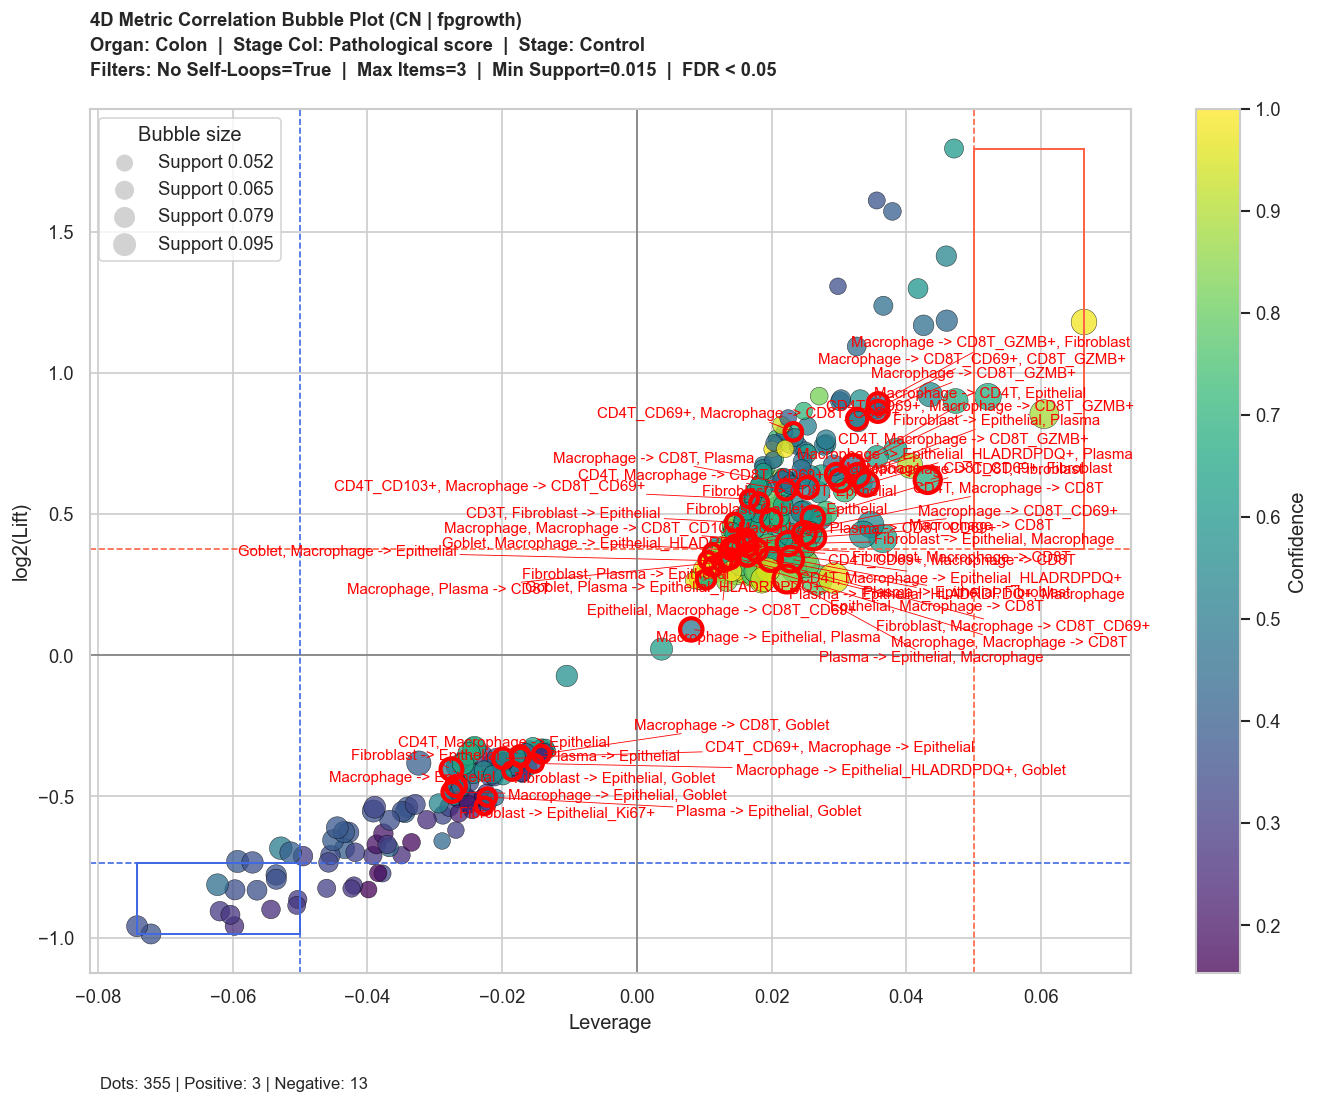

Rules in Positive Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
128,"Epithelial, Epithelial_Ki67+ -> Goblet",0.066361,2.269030,1.182076,0.981132,0.118654
116,Epithelial -> Goblet,0.060459,1.809269,0.855407,0.883269,0.149672
117,"Epithelial -> Goblet, Macrophage",0.052117,1.888664,0.917366,0.675473,0.126814


Rules in Negative Zone: 13


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
247,"Goblet -> Macrophage, Plasma",-0.074192,0.514089,-0.959909,0.351979,0.080003
244,"Goblet -> Fibroblast, Macrophage",-0.072131,0.504411,-0.987330,0.362268,0.072648
246,Goblet -> Macrophage,-0.062259,0.569299,-0.812741,0.457339,0.085779
220,"Goblet -> CD8T, Plasma",-0.061902,0.533403,-0.906702,0.298022,0.069370
230,"Goblet -> CD8T_CD69+, Plasma",-0.060335,0.528762,-0.919311,0.281859,0.065671
219,"Goblet -> CD8T, Macrophage",-0.059736,0.514331,-0.959230,0.263285,0.063262
245,"Goblet -> Fibroblast, Plasma",-0.059668,0.562233,-0.830760,0.350479,0.073708
222,"Goblet -> CD8T_CD103+, CD8T_CD69+",-0.056392,0.561665,-0.832219,0.355900,0.071634
229,"Goblet -> CD8T_CD69+, Macrophage",-0.054320,0.535731,-0.900419,0.260870,0.062681
221,Goblet -> CD8T_CD103+,-0.053547,0.583178,-0.777992,0.374313,0.075758


In [57]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Colon" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 6016
Rules count after filtering by organ: 1231
metric_df number of lines: 1231
filtered work_df: (1231, 30)
metric_df (after FDR + metric filters): (537, 8)
leverage_source: mean of per-FOV Leverage
                             Rule      Lift  Confidence   Support  Leverage  \
0               APC, CD4T -> Treg  2.505945    0.807692  0.092593  0.055643   
1       APC, Epithelial -> Goblet  1.571424    0.993750  0.076406  0.027784   
2   APC, Epithelial -> Macrophage  1.395403    0.887218  0.059356  0.016819   
3   APC, Fibroblast -> Macrophage  1.398031    0.888889  0.052314  0.014894   
4        CD3T, CD4T -> Epithelial  1.255236    0.892857  0.054885  0.011160   
5      CD3T, Epithelial -> Goblet  1.581307    1.000000  0.050457  0.018548   
6  CD3T, Fibrob

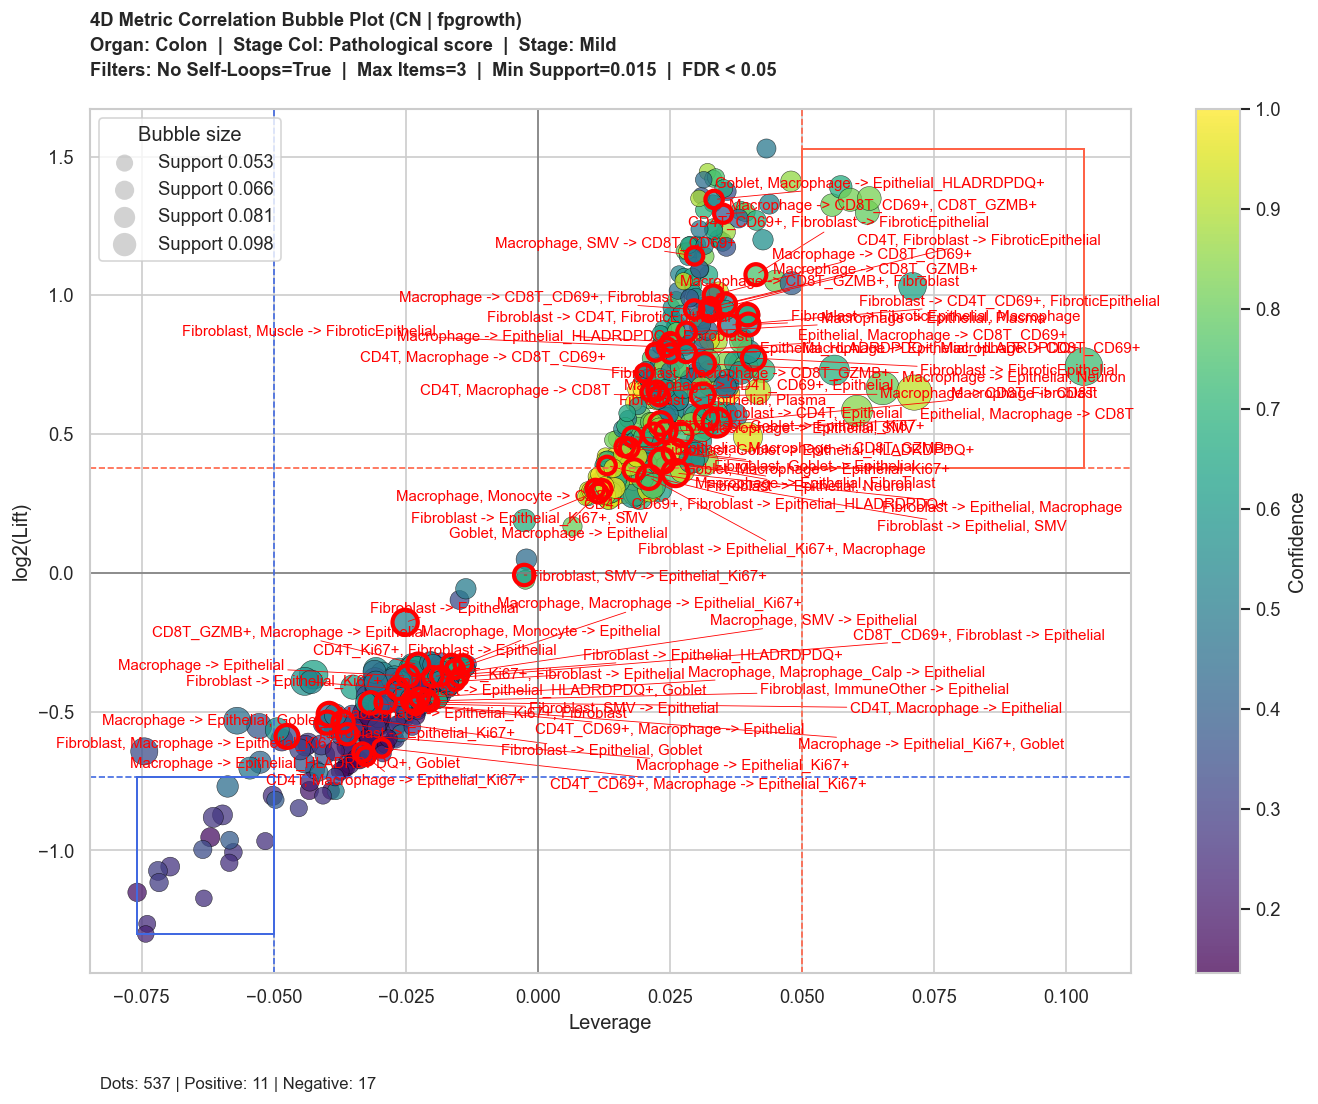

Rules in Positive Zone: 11


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
221,"Epithelial, Epithelial -> Goblet",0.103316,1.673997,0.743297,0.730061,0.256604
202,Epithelial -> Goblet,0.071196,1.568903,0.649757,0.918335,0.223739
368,"Fibroblast, Macrophage -> Neuron",0.070868,2.045828,1.032685,0.638132,0.138631
193,"Epithelial -> Fibroblast, Goblet",0.065218,1.586363,0.665723,0.801121,0.198431
91,"CD4T_CD69+, CD4T -> Treg",0.062673,2.547397,1.349024,0.821053,0.103175
44,"CD4T, CD4T -> Treg",0.062305,2.461395,1.299476,0.793333,0.104938
229,"Epithelial, Epithelial_Ki67+ -> Goblet",0.060355,1.499329,0.584317,0.843833,0.173439
51,"CD4T, CD4T_Ki67+ -> Treg",0.059072,2.539535,1.344564,0.818519,0.097443
9,"CD4T -> APC, Treg",0.057283,2.622341,1.390855,0.675241,0.092593
203,"Epithelial -> Goblet, Macrophage",0.056084,1.659591,0.730828,0.681035,0.162637


Rules in Negative Zone: 17


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
426,"Goblet -> Macrophage, Neuron",-0.075866,0.450346,-1.150893,0.182692,0.062159
427,"Goblet -> Macrophage, SMV",-0.074236,0.405905,-1.300787,0.220109,0.050720
424,"Goblet -> Fibroblast, SMV",-0.073945,0.416312,-1.264261,0.247903,0.052628
413,"Goblet -> Epithelial, SMV",-0.071919,0.475171,-1.073482,0.296709,0.065099
430,Goblet -> SMV,-0.071707,0.461556,-1.115423,0.289839,0.061665
401,"Goblet -> CD4T, Epithelial",-0.069593,0.480262,-1.058105,0.265207,0.064307
400,Goblet -> CD4T,-0.063431,0.501263,-0.996360,0.341295,0.060322
506,"Muscle -> Epithelial, Macrophage",-0.063232,0.443686,-1.172390,0.257862,0.050431
156,"Epithelial -> CD4T, CD8T",-0.062012,0.516848,-0.952187,0.172161,0.066337
428,Goblet -> Neuron,-0.061447,0.543084,-0.880754,0.274267,0.073167


In [58]:
STAGE = "Mild"  # Update this to test different stages
organ = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 1925
Rules count after filtering by organ: 952
metric_df number of lines: 952
filtered work_df: (952, 30)
metric_df (after FDR + metric filters): (400, 8)
leverage_source: mean of per-FOV Leverage
                                        Rule      Lift  Confidence   Support  \
0             CD3T, Epithelial -> Fibroblast  0.717615    0.598174  0.058771   
1                   CD4T -> CD8T_CD69+, Treg  1.814499    0.552239  0.077217   
2                  CD4T -> Plasma_CD38, Treg  2.008188    0.385572  0.053913   
3                   CD4T, CD4T -> Epithelial  0.796913    0.645570  0.052496   
4             CD4T, Macrophage -> CD8T_CD69+  1.687094    0.736842  0.071795   
5            CD4T, Macrophage -> Endothelial  1.637178    0.466387  0.054519   
6          

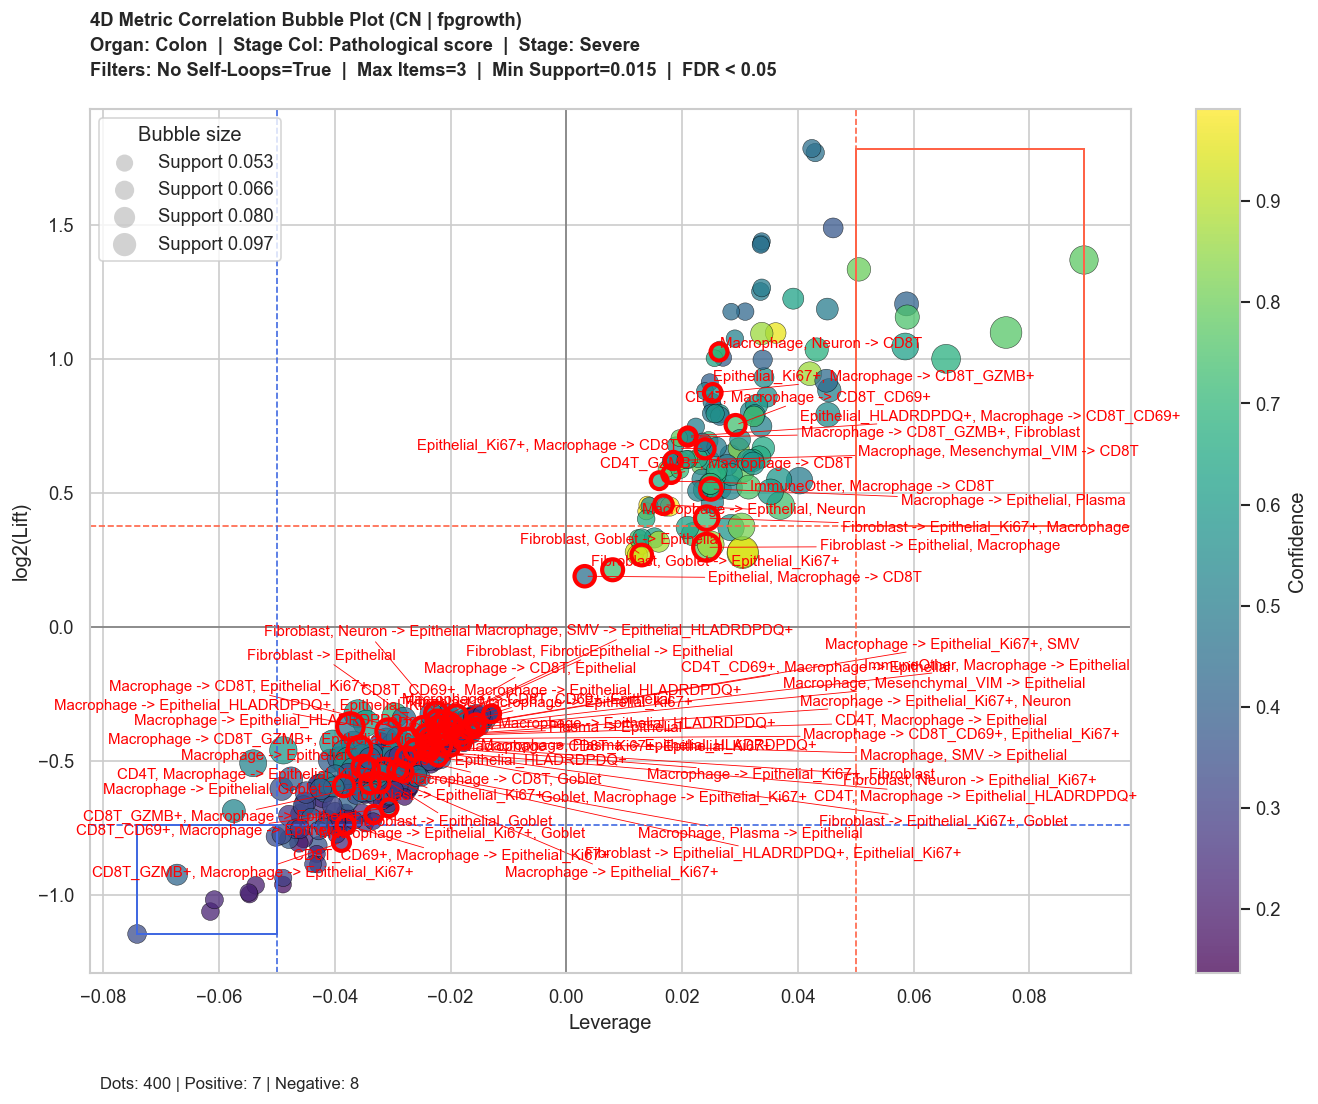

Rules in Positive Zone: 7


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
130,"Epithelial, Epithelial -> Goblet",0.089444,2.585564,1.370479,0.776504,0.145856
105,Epithelial -> Goblet,0.075971,2.143076,1.099683,0.766632,0.181205
94,"Epithelial -> Fibroblast, Goblet",0.065616,2.002190,1.001579,0.673956,0.150002
136,"Epithelial, Epithelial_Ki67+ -> Goblet",0.058903,2.230611,1.157439,0.748486,0.105751
107,"Epithelial -> Goblet, Plasma",0.058785,2.308065,1.206684,0.407921,0.103726
106,"Epithelial -> Goblet, Macrophage",0.058553,2.066943,1.047499,0.617395,0.130403
209,Epithelial_Ki67+ -> Goblet,0.050548,2.523611,1.335490,0.796849,0.099921


Rules in Negative Zone: 8


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
276,"Goblet -> Fibroblast, Macrophage",-0.074171,0.452019,-1.145546,0.337745,0.063627
277,Goblet -> Macrophage,-0.067276,0.526947,-0.924272,0.419774,0.080195
117,"Epithelial -> Macrophage, Plasma_CD38",-0.061510,0.478968,-1.061999,0.213660,0.056423
127,Epithelial -> Plasma_CD38,-0.060820,0.493845,-1.017869,0.223541,0.059139
274,"Goblet -> Epithelial_Ki67+, Macrophage",-0.054883,0.503047,-0.991235,0.218289,0.055556
50,"Epithelial -> CD4T, CD8T",-0.054750,0.500873,-0.997484,0.199906,0.053931
102,"Epithelial -> Fibroblast, Plasma_CD38",-0.053688,0.512720,-0.963757,0.205534,0.056491
383,"Neutrophil_CD15, Neutrophil -> CD8T",-0.050178,0.581746,-0.781540,0.335038,0.069792


In [59]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

## Duodenum's Highest Rules

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 3156
Rules count after filtering by organ: 1266
metric_df number of lines: 1266
filtered work_df: (1266, 30)
metric_df (after FDR + metric filters): (450, 8)
leverage_source: mean of per-FOV Leverage
                                Rule      Lift  Confidence   Support  \
0         Bcell -> CD4T, CD8T_CD103+  0.583708    0.189954  0.098672   
1         Bcell -> CD4T, Plasma_CD38  0.462893    0.097717  0.050759   
2               Bcell -> CD4T_CD103+  0.690426    0.327854  0.170304   
3   Bcell -> CD4T_CD103+, CD4T_CD69+  0.690426    0.327854  0.170304   
4   Bcell -> CD4T_CD103+, CD4T_Ki67+  0.690994    0.221918  0.115275   
5         Bcell -> CD4T_CD103+, CD8T  0.680618    0.282192  0.146584   
6  Bcell -> CD4T_CD103+, CD8T_CD103+  0.546443    0.158904  0.08

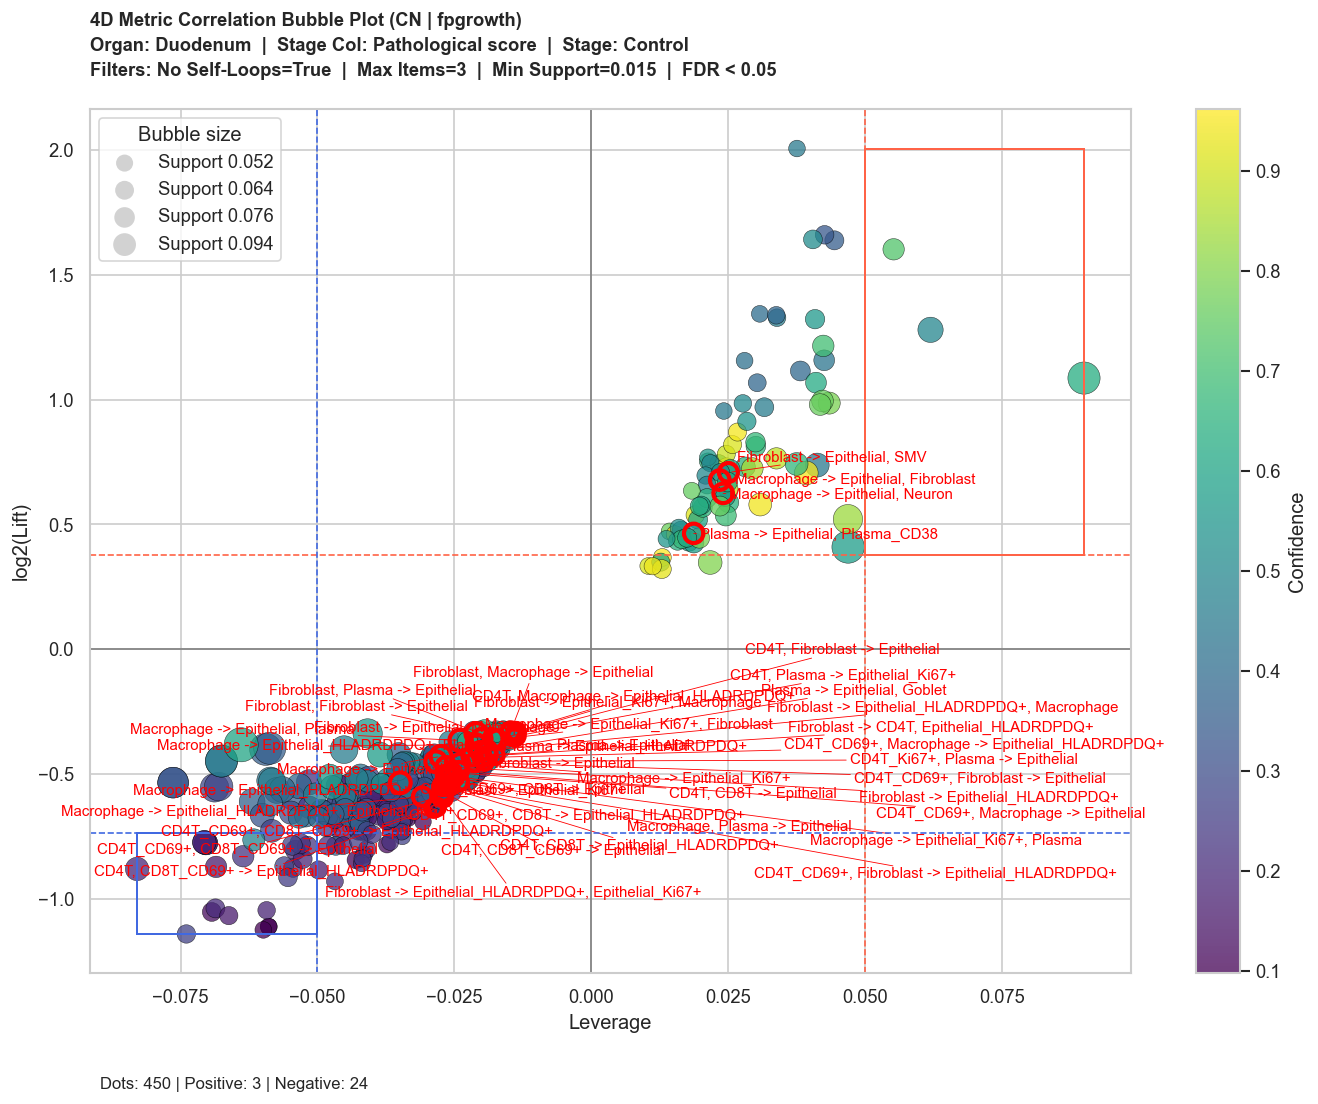

Rules in Positive Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
195,Epithelial -> Goblet,0.090000,2.123176,1.086224,0.631953,0.187102
196,"Epithelial -> Goblet, Macrophage",0.061971,2.427453,1.279443,0.494847,0.115234
246,"Epithelial, Epithelial_Ki67+ -> Goblet",0.055229,3.035681,1.602020,0.723607,0.082513


Rules in Negative Zone: 24


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
9,"Bcell -> CD4T_CD103+, Macrophage",-0.082939,0.543316,-0.880137,0.189954,0.098672
29,"CD3T, Epithelial -> Macrophage",-0.073941,0.453567,-1.140613,0.263158,0.061375
14,Bcell -> CD8T_CD103+,-0.070655,0.585056,-0.773352,0.191781,0.099620
15,"Bcell -> CD8T_CD103+, CD8T_CD69+",-0.070655,0.585056,-0.773352,0.191781,0.099620
10,"Bcell -> CD4T_CD69+, CD8T_CD103+",-0.070371,0.583708,-0.776681,0.189954,0.098672
0,"Bcell -> CD4T, CD8T_CD103+",-0.070371,0.583708,-0.776681,0.189954,0.098672
17,"Bcell -> CD8T_CD103+, Macrophage",-0.069289,0.482165,-1.052402,0.124201,0.064516
150,"Epithelial -> CD4T_GZMB+, Macrophage",-0.068631,0.486982,-1.038061,0.200561,0.065148
6,"Bcell -> CD4T_CD103+, CD8T_CD103+",-0.068512,0.546443,-0.871856,0.158904,0.082543
211,"Epithelial -> Macrophage_Calp, Plasma",-0.066195,0.477287,-1.067071,0.155499,0.060442


In [60]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Duodenum" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 6016
Rules count after filtering by organ: 4785
metric_df number of lines: 4785
filtered work_df: (4785, 30)
metric_df (after FDR + metric filters): (1273, 8)
leverage_source: mean of per-FOV Leverage
                             Rule      Lift  Confidence   Support  Leverage  \
0                     APC -> CD4T  1.271793    0.740741  0.074731  0.015971   
1               APC -> CD4T, CD8T  1.281148    0.703704  0.070995  0.015580   
2         APC -> CD4T, Fibroblast  1.359246    0.601852  0.060719  0.016048   
3         APC -> CD4T, Macrophage  1.269389    0.652778  0.065857  0.013976   
4        APC -> CD8T, Plasma_CD38  1.360920    0.555556  0.056049  0.014864   
5               APC -> CD8T_GZMB+  1.270525    0.606481  0.061186  0.013028   
6  APC -> Fibr

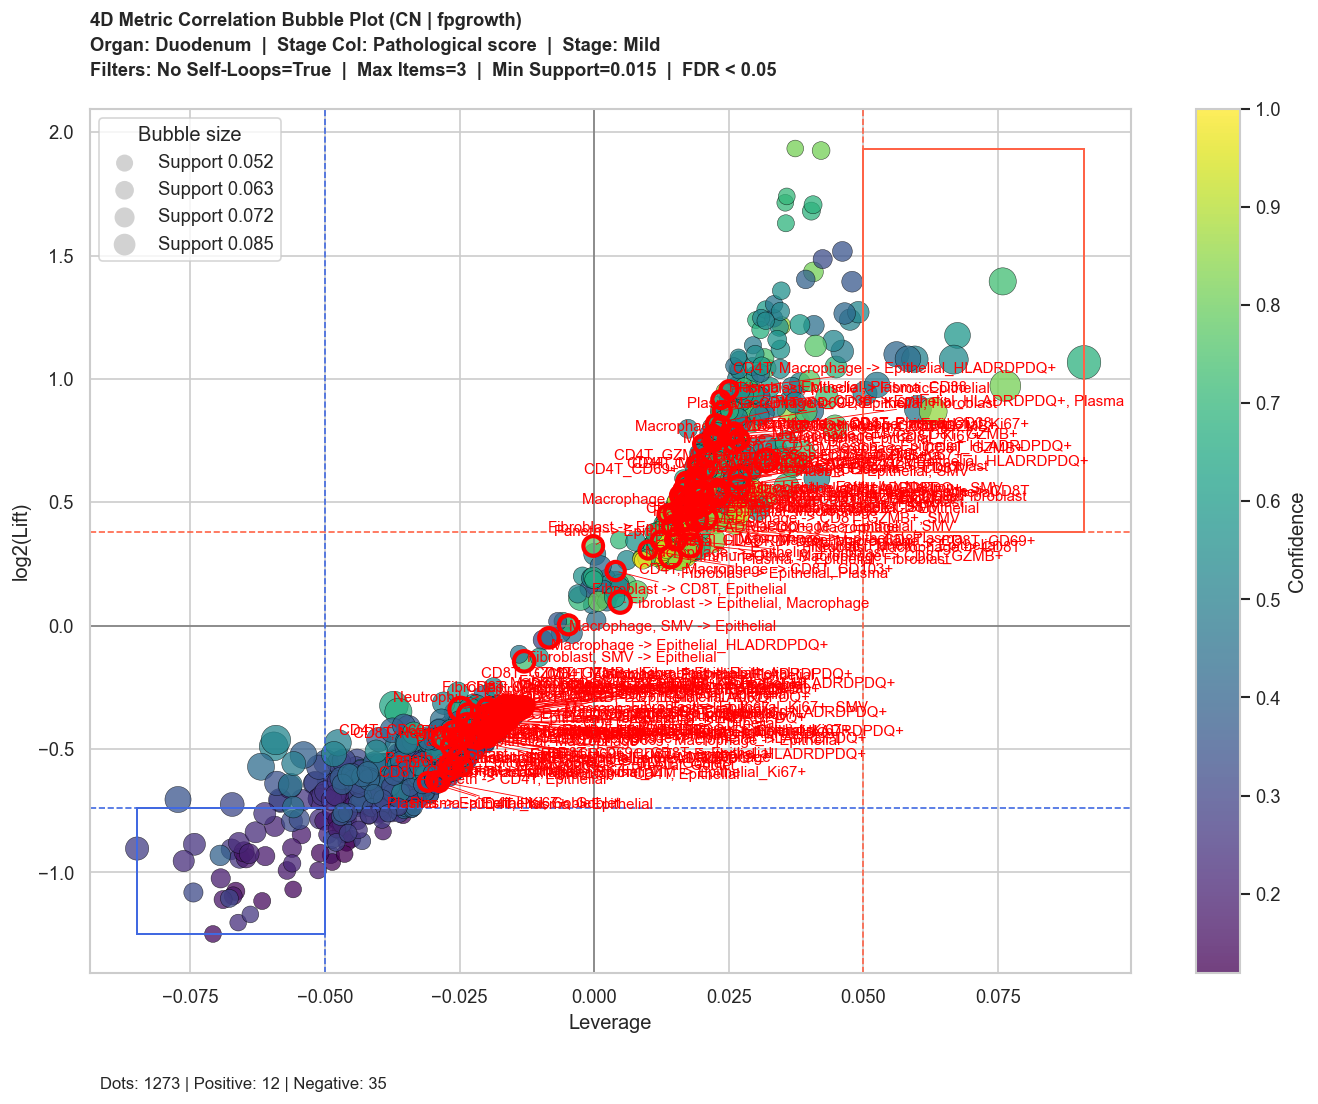

Rules in Positive Zone: 12


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
400,Epithelial -> Goblet,0.090992,2.095981,1.067626,0.681346,0.203011
472,"Epithelial, Epithelial_HLADRDPDQ+ -> Goblet",0.076380,1.961707,0.972110,0.817411,0.170702
489,"Epithelial, Epithelial_Ki67+ -> Goblet",0.075895,2.631196,1.395719,0.730691,0.133420
202,"CD8T_CD103+, Epithelial -> CD3T",0.067488,2.260656,1.176742,0.585683,0.121022
385,"Epithelial -> Fibroblast, Goblet",0.066799,2.112240,1.078774,0.536634,0.151546
610,"Epithelial, SMV -> Goblet",0.062991,1.825908,0.868614,0.857595,0.139260
181,"CD8T, Epithelial -> CD3T",0.060130,1.839221,0.879095,0.476499,0.131779
401,"Epithelial -> Goblet, Macrophage",0.059574,2.114567,1.080362,0.506405,0.126364
405,"Epithelial -> Goblet, Plasma",0.058292,2.117174,1.082140,0.432786,0.119159
280,"Epithelial -> CD4T, Goblet",0.056158,2.144153,1.100408,0.413089,0.115623


Rules in Negative Zone: 35


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
641,"Epithelial_HLADRDPDQ+ -> CD8T, Plasma",-0.084899,0.534727,-0.903125,0.276653,0.097573
645,"Epithelial_HLADRDPDQ+ -> CD8T_CD103+, Plasma",-0.076238,0.516343,-0.953598,0.230769,0.081390
19,BrunnerGland -> Epithelial,-0.074438,0.472644,-1.081175,0.312925,0.066715
636,"Epithelial_HLADRDPDQ+ -> CD8T, Fibroblast",-0.074247,0.541189,-0.885797,0.248313,0.087577
679,"Epithelial_HLADRDPDQ+ -> Plasma_CD38, Plasma",-0.070803,0.420630,-1.249376,0.145749,0.051404
1060,"Muscle -> CD8T, Fibroblast",-0.069450,0.524546,-0.930859,0.390782,0.076621
675,Epithelial_HLADRDPDQ+ -> Mesenchymal_VIM,-0.069365,0.491741,-1.024029,0.190283,0.067111
672,"Epithelial_HLADRDPDQ+ -> Macrophage, Plasma_CD38",-0.068923,0.463294,-1.110001,0.168691,0.059495
1050,"Muscle -> APC, Fibroblast",-0.067759,0.464821,-1.105252,0.311111,0.058851
203,"CD8T_CD103+, Epithelial -> Fibroblast",-0.067377,0.533670,-0.905980,0.262136,0.077106


In [61]:
STAGE = "Mild"  # Update this to test different stages
organ = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 1925
Rules count after filtering by organ: 973
metric_df number of lines: 973
filtered work_df: (973, 30)
metric_df (after FDR + metric filters): (600, 8)
leverage_source: mean of per-FOV Leverage
                                        Rule      Lift  Confidence   Support  \
0             APC, Fibroblast -> ImmuneOther  1.328327    0.779874  0.051559   
1                 BrunnerGland -> Macrophage  0.678820    0.594203  0.056787   
2  CD3T, Epithelial_HLADRDPDQ+ -> Macrophage  0.688219    0.472561  0.078720   
3           CD3T, Fibroblast -> Unidentified  0.773104    0.331269  0.058856   
4             CD3T, Macrophage -> CD8T_GZMB+  1.529705    0.556180  0.054455   
5                        CD3T, SMV -> Plasma  1.234310    0.827778  0.065784   
6          

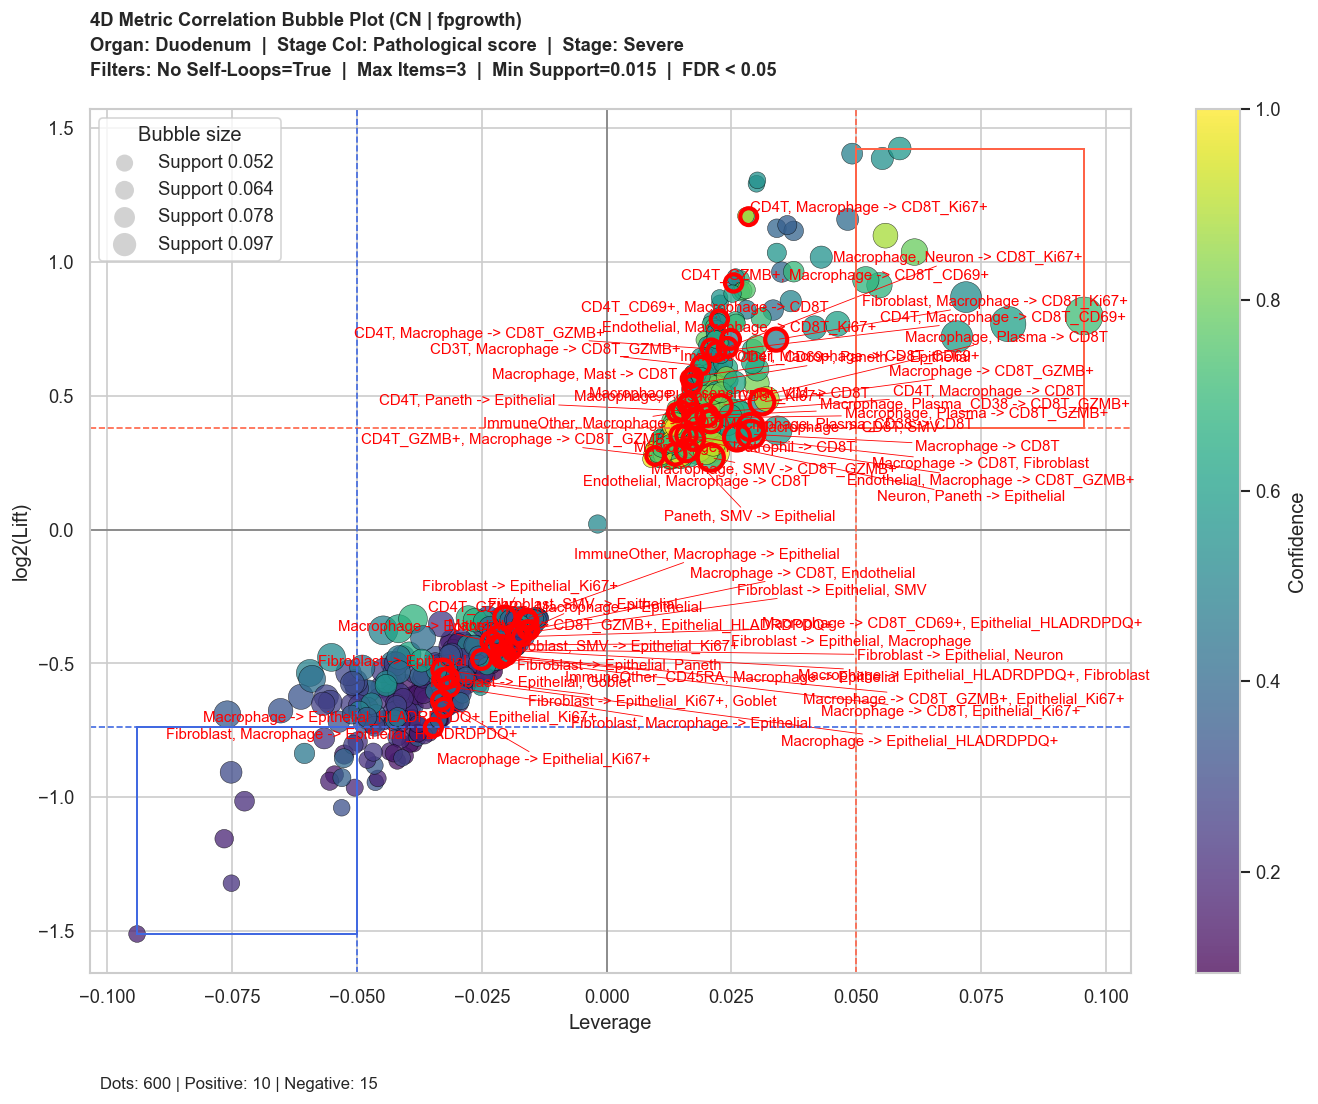

Rules in Positive Zone: 10


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
174,Epithelial -> Goblet,0.095620,1.739546,0.798711,0.713992,0.256976
163,"Epithelial -> Fibroblast, Goblet",0.080449,1.703337,0.768364,0.611386,0.223550
175,"Epithelial -> Goblet, Macrophage",0.071980,1.826577,0.869142,0.531176,0.171838
214,"Epithelial, Epithelial_Ki67+ -> Endocrine",0.070158,1.649491,0.722021,0.590840,0.178177
296,Epithelial_Ki67+ -> Goblet,0.061674,2.052592,1.037447,0.789073,0.128039
183,"Epithelial -> Macrophage, Paneth",0.058699,2.684032,1.424402,0.572519,0.093555
197,Epithelial -> Paneth,0.055841,2.141637,1.098714,0.876409,0.111368
169,"Epithelial -> Fibroblast, Paneth",0.055220,2.615731,1.387214,0.547074,0.089397
239,"Epithelial, Neuron -> Endocrine",0.054639,1.883517,0.913429,0.674667,0.116483
291,"Epithelial_Ki67+ -> Fibroblast, Goblet",0.051904,1.910366,0.933849,0.680549,0.125970


Rules in Negative Zone: 15


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
519,"Muscle -> Fibroblast, Mesenchymal_VIM",-0.094071,0.350927,-1.510758,0.174807,0.050860
267,"Epithelial_HLADRDPDQ+ -> Macrophage, Plasma",-0.076620,0.449127,-1.154806,0.180882,0.062468
528,Muscle -> Mesenchymal_VIM,-0.075238,0.533410,-0.906682,0.295630,0.086013
132,"Epithelial -> CD8T, Neuron",-0.075177,0.400244,-1.321049,0.220370,0.050169
269,Epithelial_HLADRDPDQ+ -> Plasma,-0.072547,0.494972,-1.014580,0.205882,0.071102
532,"Muscle, SMV -> Fibroblast",-0.060537,0.560238,-0.835888,0.454308,0.075181
186,"Epithelial -> Macrophage, SMV",-0.056595,0.582455,-0.779781,0.231824,0.080403
245,"Epithelial_HLADRDPDQ+ -> CD4T, Plasma",-0.055499,0.521293,-0.939832,0.175000,0.060437
116,"Epithelial -> CD4T_CD69+, Plasma",-0.054528,0.530002,-0.915929,0.142326,0.058822
517,"Muscle -> Fibroblast, ImmuneOther",-0.053087,0.486657,-1.039024,0.315457,0.050327


In [62]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

In [63]:
zone_summary_df = _summarize_threshold_zones(metric_df)
display(zone_summary_df)

print('\nMean values of the wanted subset:')
display(metric_df[["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]].mean().to_frame(name="Mean"))


,Zone,Count,Percent
0,Positive zone,10,1.67
1,Negative zone,15,2.50
2,Noise zone,1,0.17
3,Total,600,100.00



Mean values of the wanted subset:


,Mean
Leverage,-0.008156
Lift,1.038098
Log2_Lift,-0.063502
Confidence,0.471142
Support,0.070548


## Automated Manager Report Generation
Run this cell to automatically generate a multi-page PDF containing bubble plots and highlight tables.

In [64]:
import glob
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Define combinations
organs_to_run = ["Colon", "Duodenum"]
stages_to_run = ["Control", "Mild", "Severe"]

# 2. Find next running ID
existing_reports = glob.glob("reports/bubble_metrics_report_*.pdf")
ids = []
for f in existing_reports:
    try:
        num_str = f.split("_")[-1].replace(".pdf", "")
        ids.append(int(num_str))
    except ValueError:
        pass
next_id = max(ids) + 1 if ids else 1

report_filename = f"reports/bubble_metrics_report_{next_id:03d}.pdf"
print(f"Generating PDF Report: {report_filename}...")

# 3. Create PDF
with PdfPages(report_filename) as pdf:
    for organ in organs_to_run:
        
        # A. Plot Bubble Charts per Stage
        for stage in stages_to_run:
            print(f"-> Processing Organ: {organ} | Stage: {stage}")
            
            ORGAN = organ
            STAGE = stage
            
            work_df = _create_basic_dataset(raw_results_df)
            if not work_df.empty:
                metric_df, leverage_source = _build_metric_bubble_df(work_df)
                if not metric_df.empty:
                    fig = _plot_metric_bubble(metric_df, leverage_source)
                    if fig is not None:
                        pdf.savefig(fig, bbox_inches='tight')
                        plt.close(fig)
        
        # B. Append the Highlighted Rules Summary Table at the end of the organ's section
        print(f"-> Appending Highlighted Rules Table for Organ: {organ}")
        table_fig = _plot_highlight_rules_table(organ)
        if table_fig is not None:
            pdf.savefig(table_fig, bbox_inches='tight')
            plt.close(table_fig)

print("✅ PDF Report Generation Complete!")

Generating PDF Report: reports/bubble_metrics_report_004.pdf...
-> Processing Organ: Colon | Stage: Control
Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 3156
Rules count after filtering by organ: 898
metric_df number of lines: 898
-> Processing Organ: Colon | Stage: Mild
Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support: 11097
Rules count after filtering by stage: 6016
Rules count after filtering by organ: 1231
metric_df number of lines: 1231
-> Processing Organ: Colon | Stage: Severe
Initial rules count: 67122
Rules count after removing self-overlapping rules: 24737
Rules count after filtering by subset rule items: 11097
Rules count after filtering by minimum support